Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 0.6587 - mse: 0.0750 - val_loss: 0.1393 - val_mse: 0.0123
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.1304 - mse: 0.0115 - val_loss: 0.0974 - val_mse: 0.0087
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0909 - mse: 0.0081 - val_loss: 0.0754 - val_mse: 0.0068
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0745 - mse: 0.0067 - val_loss: 0.0652 - val_mse: 0.0058
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0650 - mse: 0.0058 - val_loss: 0.0575 - val_mse: 0.0052
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0576 - mse: 0.0052 - val_loss: 0.0525 - val_mse: 0.0047
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0529 - mse: 0.0048 - val_loss: 0.0489 - val_mse: 0.0044
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0490 - mse: 0.0044 - val_loss: 0.0461 - val_mse: 0.0041
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms

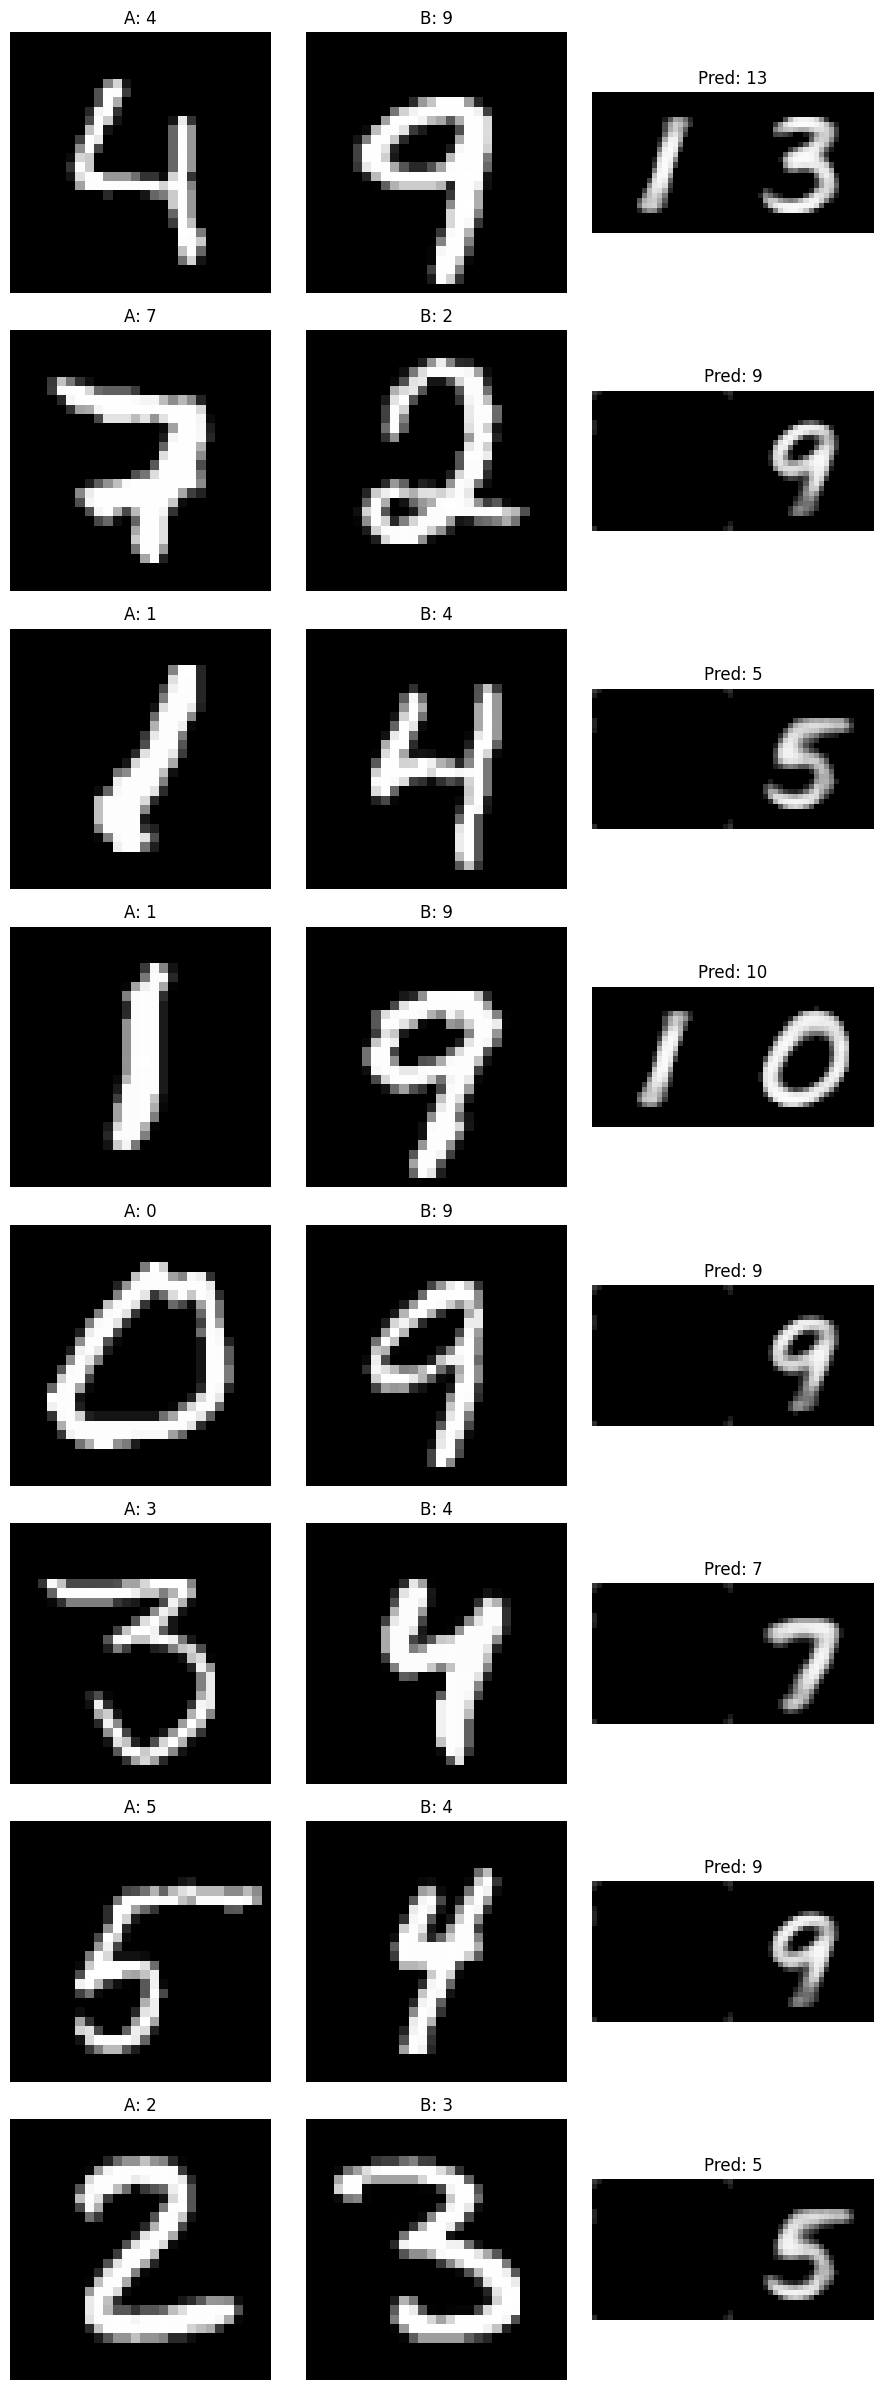

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt


#loss for training of autoencoder
def custom_loss(y_true, y_pred):
    mse = tf.keras.losses.MeanSquaredError()(y_true, y_pred)
    ssim = tf.reduce_mean(1 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    loss = mse + ssim + 0.1 * l1_loss
    return loss

def AutoencoderWithConvLayers(input_shape, latent_dim):
    # Encoder Part
    encoder_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)

    # Decoder Part
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
    x = layers.Reshape((7, 7, 128))(x)
    x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2DTranspose(1, (3, 3), activation='sigmoid', padding='same')(x)

    # Create Models
    encoder = models.Model(encoder_input, latent, name="Encoder")
    decoder = models.Model(decoder_input, decoder_output, name="Decoder")
    autoencoder = models.Model(encoder_input, decoder(encoder(encoder_input)), name="Autoencoder")

    return encoder, decoder, autoencoder

# training for autoencoder
# Reshape  Conv2D (28, 28, 1)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

input_shape = (28, 28, 1)
latent_dim = 512  # High dimension for better quality

encoder, decoder, autoencoder = AutoencoderWithConvLayers(input_shape, latent_dim)

autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                    loss=custom_loss,
                    metrics=['mse'])



autoencoder.fit(x_train, x_train,
                epochs=15,  # 15 epochs to avoid overfitting
                batch_size=128,
                validation_data=(x_test, x_test))

# weight freezing
encoder.trainable = False
decoder.trainable = False
print("\n Real Latents")
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Average of digits
digit_averages = np.zeros((10, latent_dim))
for i in range(10):
    imgs = x_train[y_train == i]
    # improvement of average
    latents = encoder.predict(imgs[:500], verbose=0)
    digit_averages[i] = np.mean(latents, axis=0)

# blank image that represents no tens
blank_latent = encoder.predict(np.zeros((1, 28, 28, 1)), verbose=0)[0]

def generate_robust_sum_data(num_samples=50000):

    idx_a = np.random.randint(0, len(x_train), num_samples)
    idx_b = np.random.randint(0, len(x_train), num_samples)

    imgs_a = x_train[idx_a]
    imgs_b = x_train[idx_b]

    print("Generating input latents from real images...")
    # inputs for adder network
    z_input_a = encoder.predict(imgs_a, batch_size=512, verbose=1)
    z_input_b = encoder.predict(imgs_b, batch_size=512, verbose=1)

    # TARGETS
    z_target_tens = np.zeros((num_samples, latent_dim))
    z_target_units = np.zeros((num_samples, latent_dim))

    vals_a = y_train[idx_a]
    vals_b = y_train[idx_b]

    for i in range(num_samples):
        total = vals_a[i] + vals_b[i]
        tens = total // 10
        units = total % 10

        # clean average of the digit
        z_target_units[i] = digit_averages[units]
        if tens == 0:
            z_target_tens[i] = blank_latent
        else:
            z_target_tens[i] = digit_averages[tens]

    return [z_input_a, z_input_b], [z_target_tens, z_target_units]

# big dataset for training, 5000 samples
X_adder, Y_adder = generate_robust_sum_data(50000)

# Training of adder

input_z_a = Input(shape=(latent_dim,))
input_z_b = Input(shape=(latent_dim,))

merged = layers.Concatenate()([input_z_a, input_z_b])

# MLP for the sum of the digits
x = layers.Dense(1024)(merged) #1024
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(512)(x) #512
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)

# Heads output
pred_tens = layers.Dense(latent_dim, name="Tens")(x)
pred_units = layers.Dense(latent_dim, name="Units")(x)

adder_model = models.Model([input_z_a, input_z_b], [pred_tens, pred_units])

#
# mae is less sensitive to outliers and works better for regression latent spaaces
adder_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mae')

adder_callbacks = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

print("\nTraining Adder ")

adder_model.fit(X_adder, Y_adder,
                epochs=100,
                batch_size=256,
                validation_split=0.1,
                callbacks=adder_callbacks)



real_in_a = Input(shape=(28, 28, 1))
real_in_b = Input(shape=(28, 28, 1))

# 1. Encode (Real noisy images)
lat_a = encoder(real_in_a)
lat_b = encoder(real_in_b)

# 2. Add (Trained to handle noise but map to clean targets)
tens_lat, units_lat = adder_model([lat_a, lat_b])

# 3. Decode (Prints clean images from clean targets)
img_tens = decoder(tens_lat)
img_units = decoder(units_lat)

full_model = models.Model([real_in_a, real_in_b], [img_tens, img_units])

def visualize_results_robust(n=5):
    # dificult examples for test set
    idxs = np.random.choice(len(x_test), n*2, replace=False)
    samp_a = x_test[idxs[:n]]
    samp_b = x_test[idxs[n:]]
    lbl_a = y_test[idxs[:n]]
    lbl_b = y_test[idxs[n:]]

    print("Predicting...")
    out_tens, out_units = full_model.predict([samp_a, samp_b], verbose=0)

    plt.figure(figsize=(12, 3*n))
    for i in range(n):
        expected_sum = lbl_a[i] + lbl_b[i]

        # A
        plt.subplot(n, 4, i*4 + 1)
        plt.imshow(samp_a[i].squeeze(), cmap='gray')
        plt.title(f"A: {lbl_a[i]}")
        plt.axis('off')

        # B
        plt.subplot(n, 4, i*4 + 2)
        plt.imshow(samp_b[i].squeeze(), cmap='gray')
        plt.title(f"B: {lbl_b[i]}")
        plt.axis('off')

        # Result
        # values <0.1 mean blank
        res_t = np.clip(out_tens[i].squeeze(), 0, 1)
        res_u = np.clip(out_units[i].squeeze(), 0, 1)
        res_t[res_t < 0.1] = 0
        res_u[res_u < 0.1] = 0

        combined = np.hstack((res_t, res_u))

        plt.subplot(n, 4, i*4 + 3)
        plt.imshow(combined, cmap='gray', vmin=0, vmax=1)
        plt.title(f"Pred: {expected_sum}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_results_robust(8)

In [12]:
#working on the whole dataset
#if 'classifier' not in locals():
def build_classifier():
        model = models.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(8, (3, 3), activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(8, (3, 3), activation='relu'),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(8, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model


classifier = build_classifier()
classifier.fit(x_train, y_train, epochs=5, batch_size=128, verbose=0)


#evaluation
def evaluate_full_test_set():

    midpoint = len(x_test) // 2

    samp_a = x_test[:midpoint]      # first 5000 samples
    samp_b = x_test[midpoint:]
    lbl_a = y_test[:midpoint]
    lbl_b = y_test[midpoint:]

    num_samples = len(samp_a) # 5000

    # Ground Truth
    true_sums = lbl_a + lbl_b



    # Batch prediction to prevent full memory capacity
    pred_imgs_tens, pred_imgs_units = full_model.predict([samp_a, samp_b], batch_size=128, verbose=1)


    # predictions
    unit_preds_probs = classifier.predict(pred_imgs_units, batch_size=128, verbose=1)
    pred_labels_units = np.argmax(unit_preds_probs, axis=1)

    tens_preds_probs = classifier.predict(pred_imgs_tens, batch_size=128, verbose=1)

    pred_labels_tens = []

    # Leading zero- blank
    for i in range(num_samples):
        # if theres no lightness, consider 0
        if np.mean(pred_imgs_tens[i]) < 0.05:
            pred_labels_tens.append(0)
        else:
            pred_labels_tens.append(np.argmax(tens_preds_probs[i]))

    pred_labels_tens = np.array(pred_labels_tens)

    # prediction
    read_sums = (pred_labels_tens * 10) + pred_labels_units

    correct_predictions = np.sum(read_sums == true_sums)
    accuracy = correct_predictions / num_samples


    print(f"Samples: {num_samples}")
    print(f"Correct Predictions: {correct_predictions}")
    print(f"False Predictions: {num_samples - correct_predictions}")
    print(f" ACCURACY: {accuracy * 100:.2f}%")

    # errors
    mistake_indices = np.where(read_sums != true_sums)[0]
    if len(mistake_indices) > 0:
        mean_abs_error = np.mean(np.abs(read_sums[mistake_indices] - true_sums[mistake_indices]))
        print(f"Mean Error in False Preds: {mean_abs_error:.2f}")

# evaluation
evaluate_full_test_set()

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Samples: 5000
Correct Predictions: 4551
False Predictions: 449
 ACCURACY: 91.02%
Mean Error in False Preds: 4.82


Generating predictions for 5,000 pairs...
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

FINAL ACCURACY: 90.92%


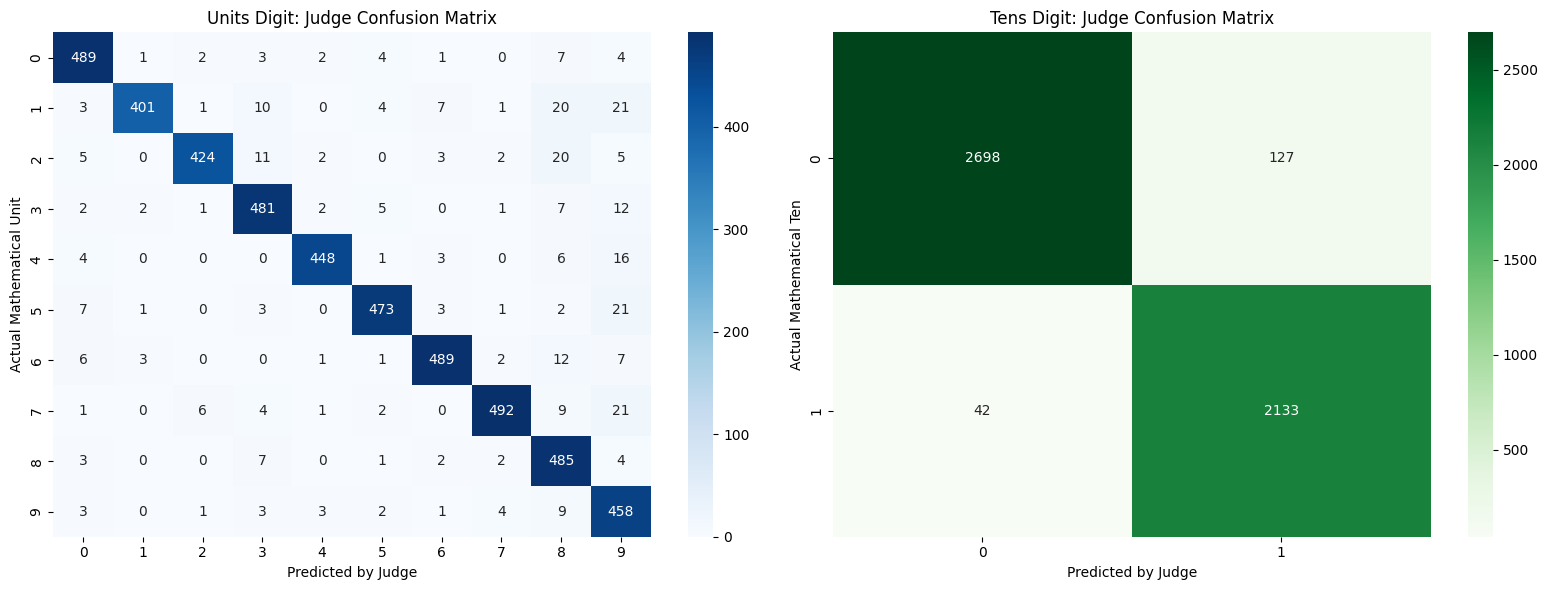

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_and_plot_confusion():
    #  Prepare Test Pairs
    midpoint = len(x_test) // 2
    samp_a, samp_b = x_test[:midpoint], x_test[midpoint:]
    lbl_a, lbl_b = y_test[:midpoint], y_test[midpoint:]
    true_sums = lbl_a + lbl_b

    # Ground Truth for individual heads
    true_labels_tens = true_sums // 10
    true_labels_units = true_sums % 10

    #  Generate Predictions
    print("Generating predictions for 5,000 pairs...")
    pred_imgs_tens, pred_imgs_units = full_model.predict([samp_a, samp_b], batch_size=128)

    #  Judge reads the images
    # Units logic
    unit_preds_probs = classifier.predict(pred_imgs_units, batch_size=128)
    pred_labels_units = np.argmax(unit_preds_probs, axis=1)

    # Tens logic with Brightness Threshold
    tens_preds_probs = classifier.predict(pred_imgs_tens, batch_size=128)
    pred_labels_tens = []
    for i in range(len(samp_a)):
        if np.mean(pred_imgs_tens[i]) < 0.05: # Threshold check
            pred_labels_tens.append(0)
        else:
            pred_labels_tens.append(np.argmax(tens_preds_probs[i]))
    pred_labels_tens = np.array(pred_labels_tens)

    # Final Accuracy
    read_sums = (pred_labels_tens * 10) + pred_labels_units
    accuracy = np.mean(read_sums == true_sums)
    print(f"\nFINAL ACCURACY: {accuracy * 100:.2f}%")

    #  VISUALIZATION: Confusion Matrices
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Units Matrix
    cm_units = confusion_matrix(true_labels_units, pred_labels_units)
    sns.heatmap(cm_units, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title('Units Digit: Judge Confusion Matrix')
    ax1.set_xlabel('Predicted by Judge')
    ax1.set_ylabel('Actual Mathematical Unit')

    # Tens Matrix
    cm_tens = confusion_matrix(true_labels_tens, pred_labels_tens)
    sns.heatmap(cm_tens, annot=True, fmt='d', cmap='Greens', ax=ax2)
    ax2.set_title('Tens Digit: Judge Confusion Matrix')
    ax2.set_xlabel('Predicted by Judge')
    ax2.set_ylabel('Actual Mathematical Ten')

    plt.tight_layout()
    plt.show()

# Run the integrated evaluation
evaluate_and_plot_confusion()


--- Αναζήτηση των 5 καλύτερων αποτελεσμάτων σε 1000 δείγματα ---


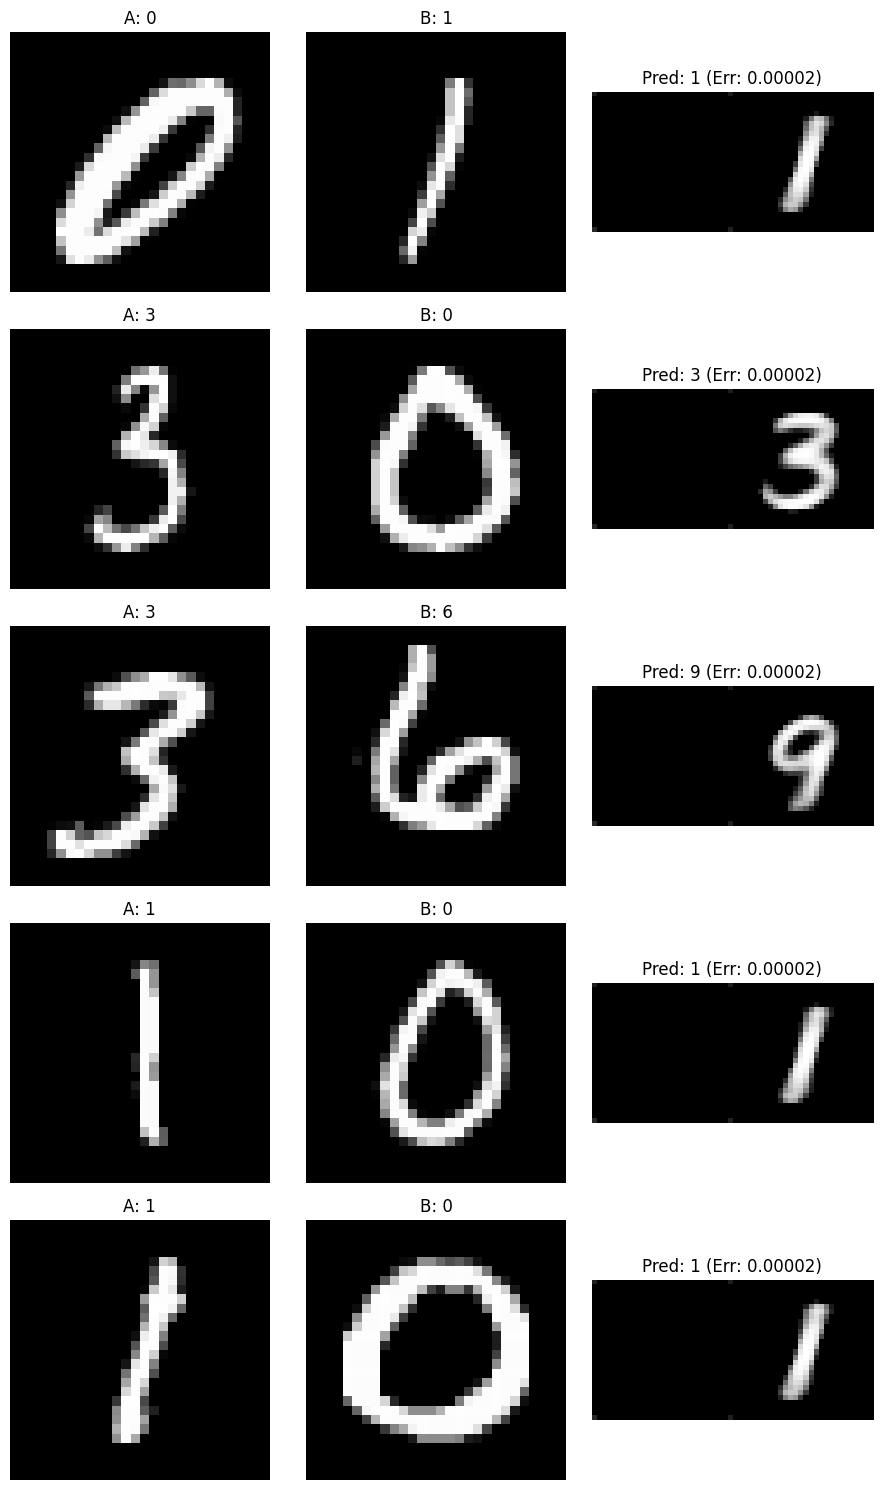

In [ ]:
def show_best_predictions(n=5, sample_size=1000):


    # random samples
    idxs = np.random.choice(len(x_test), sample_size * 2, replace=False)
    samp_a = x_test[idxs[:sample_size]]
    samp_b = x_test[idxs[sample_size:]]
    lbl_a = y_test[idxs[:sample_size]]
    lbl_b = y_test[idxs[sample_size:]]

    #predictions
    pred_tens, pred_units = full_model.predict([samp_a, samp_b], verbose=0)

    # taking the averages of digits
    ideal_digits = decoder.predict(digit_averages, verbose=0)
    ideal_blank = decoder.predict(np.array([blank_latent]), verbose=0) # for the blank image

    errors = []

    for i in range(sample_size):
        real_sum = lbl_a[i] + lbl_b[i]
        real_t = real_sum // 10
        real_u = real_sum % 10


        if real_t == 0:
            target_img_tens = ideal_blank[0]
        else:
            target_img_tens = ideal_digits[real_t]


        target_img_units = ideal_digits[real_u]


        err_t = np.mean((pred_tens[i] - target_img_tens) ** 2)
        err_u = np.mean((pred_units[i] - target_img_units) ** 2)

        total_error = err_t + err_u
        errors.append(total_error)

    errors = np.array(errors)

    # indices with minimum error
    best_indices = np.argsort(errors)[:n]


    plt.figure(figsize=(12, 3 * n))

    for i, idx in enumerate(best_indices):
        #
        plt.subplot(n, 4, i * 4 + 1)
        plt.imshow(samp_a[idx].squeeze(), cmap='gray')
        plt.title(f"A: {lbl_a[idx]}")
        plt.axis('off')

        plt.subplot(n, 4, i * 4 + 2)
        plt.imshow(samp_b[idx].squeeze(), cmap='gray')
        plt.title(f"B: {lbl_b[idx]}")
        plt.axis('off')



        img_t = np.clip(pred_tens[idx].squeeze(), 0, 1)
        img_u = np.clip(pred_units[idx].squeeze(), 0, 1)

        # blank
        img_t[img_t < 0.1] = 0
        img_u[img_u < 0.1] = 0

        combined = np.hstack((img_t, img_u))

        plt.subplot(n, 4, i * 4 + 3)
        plt.imshow(combined, cmap='gray')
        plt.title(f"Pred: {lbl_a[idx] + lbl_b[idx]} (Err: {errors[idx]:.5f})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


show_best_predictions(n=5)


--- Αναζήτηση των 100 καλύτερων ΔΙΨΗΦΙΩΝ (>=10) σε 5000 δείγματα ---


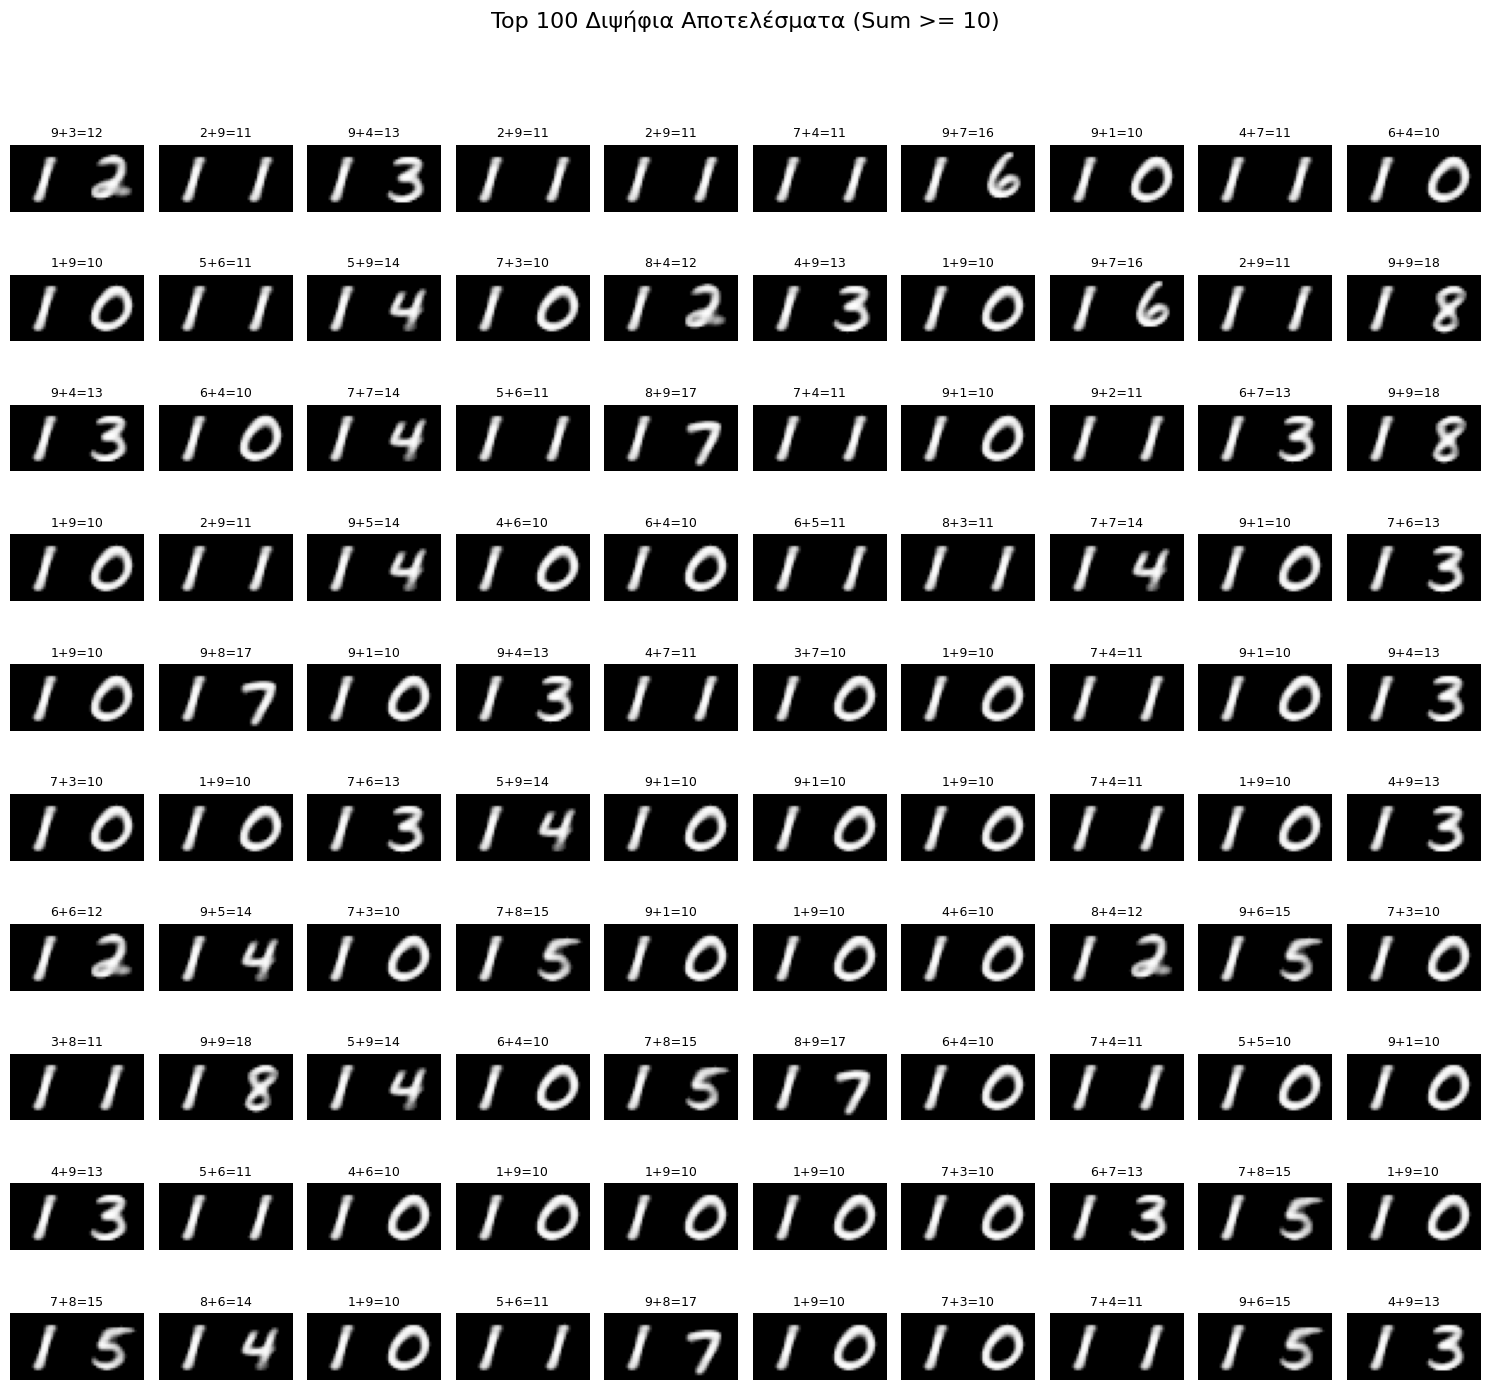

In [ ]:
def show_top_100_only_double_digits(sample_size=5000):


    # randok samples
    idxs = np.random.choice(len(x_test), sample_size * 2, replace=False)
    samp_a = x_test[idxs[:sample_size]]
    samp_b = x_test[idxs[sample_size:]]
    lbl_a = y_test[idxs[:sample_size]]
    lbl_b = y_test[idxs[sample_size:]]

    # predictions
    pred_tens, pred_units = full_model.predict([samp_a, samp_b], verbose=0)
    ideal_digits = decoder.predict(digit_averages, verbose=0)
    double_digit_errors = []
    double_digit_indices = []

    for i in range(sample_size):
        real_sum = lbl_a[i] + lbl_b[i]

        # >=10 sums
        if real_sum >= 10:
            real_t = real_sum // 10
            real_u = real_sum % 10

            target_img_tens = ideal_digits[real_t]
            target_img_units = ideal_digits[real_u]

            # error calculations
            err = np.mean((pred_tens[i] - target_img_tens)**2) + \
                  np.mean((pred_units[i] - target_img_units)**2)

            double_digit_errors.append(err)
            double_digit_indices.append(i) # we keep the initial index

    # convertion to numpy arrays
    double_digit_errors = np.array(double_digit_errors)
    double_digit_indices = np.array(double_digit_indices)


    if len(double_digit_indices) < 100:
        print(f"Προσοχή: Βρέθηκαν μόνο {len(double_digit_indices)} διψήφια δείγματα.")
        count = len(double_digit_indices)
    else:
        count = 100


    sorted_local_indices = np.argsort(double_digit_errors)[:count]


    best_indices = double_digit_indices[sorted_local_indices]


    plt.figure(figsize=(15, 15))
    plt.suptitle("Top 100 Διψήφια Αποτελέσματα (Sum >= 10)", fontsize=16)

    for i, idx in enumerate(best_indices):
        plt.subplot(10, 10, i + 1)

        # image cleaning
        t_img = np.clip(pred_tens[idx].squeeze(), 0, 1)
        u_img = np.clip(pred_units[idx].squeeze(), 0, 1)
        t_img[t_img < 0.1] = 0
        u_img[u_img < 0.1] = 0

        combined = np.hstack((t_img, u_img))

        plt.imshow(combined, cmap='gray')

        act_sum = lbl_a[idx] + lbl_b[idx]
        plt.title(f"{lbl_a[idx]}+{lbl_b[idx]}={act_sum}", fontsize=9)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_top_100_only_double_digits()


--- Αναζήτηση των 100 ΧΕΙΡΟΤΕΡΩΝ ΔΙΨΗΦΙΩΝ (>=10) σε 5000 δείγματα ---


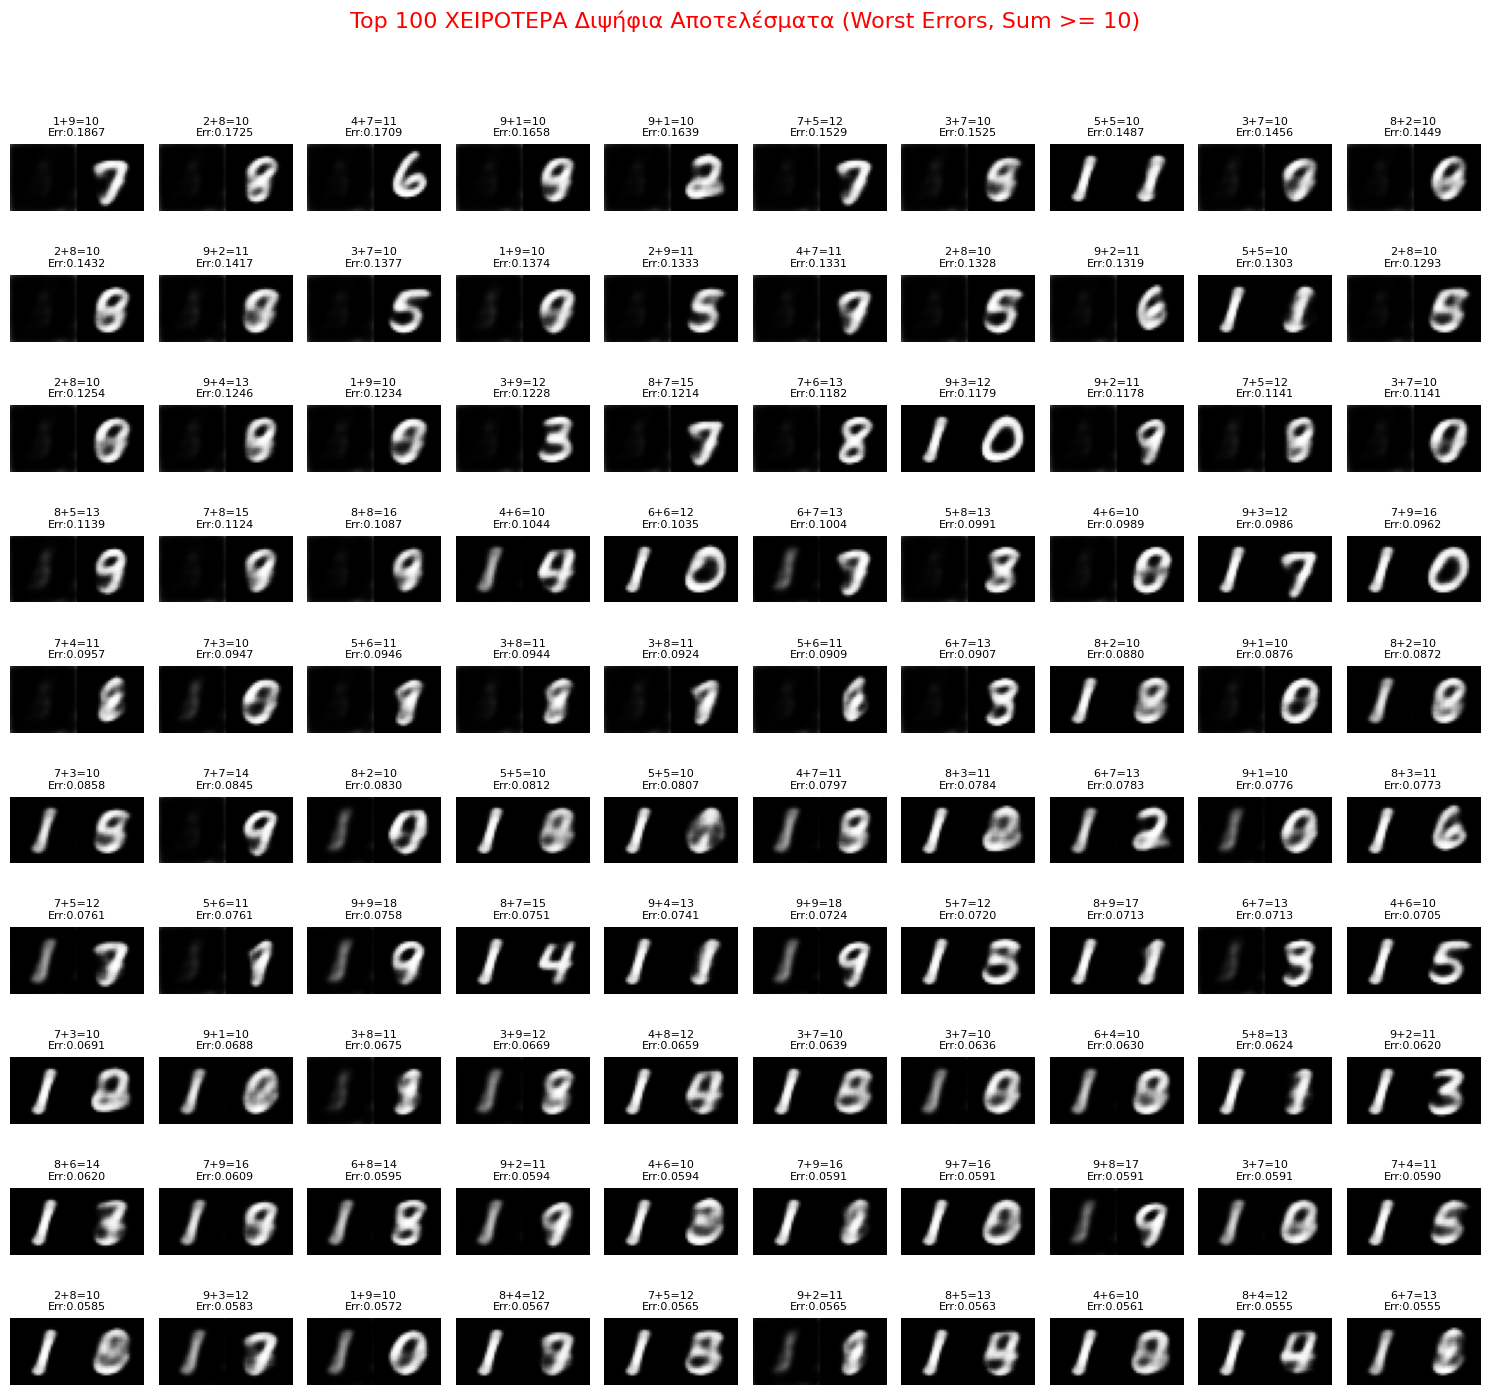

In [ ]:
def show_worst_100_only_double_digits(sample_size=5000):
    print(f"\n--- Αναζήτηση των 100 ΧΕΙΡΟΤΕΡΩΝ ΔΙΨΗΦΙΩΝ (>=10) σε {sample_size} δείγματα ---")


    idxs = np.random.choice(len(x_test), sample_size * 2, replace=False)
    samp_a = x_test[idxs[:sample_size]]
    samp_b = x_test[idxs[sample_size:]]
    lbl_a = y_test[idxs[:sample_size]]
    lbl_b = y_test[idxs[sample_size:]]


    pred_tens, pred_units = full_model.predict([samp_a, samp_b], verbose=0)


    ideal_digits = decoder.predict(digit_averages, verbose=0)


    double_digit_errors = []
    double_digit_indices = []

    for i in range(sample_size):
        real_sum = lbl_a[i] + lbl_b[i]

        # only double digit summary
        if real_sum >= 10:
            real_t = real_sum // 10
            real_u = real_sum % 10

            target_img_tens = ideal_digits[real_t]
            target_img_units = ideal_digits[real_u]


            err = np.mean((pred_tens[i] - target_img_tens)**2) + \
                  np.mean((pred_units[i] - target_img_units)**2)

            double_digit_errors.append(err)
            double_digit_indices.append(i)

    #  numpy
    double_digit_errors = np.array(double_digit_errors)
    double_digit_indices = np.array(double_digit_indices)


    if len(double_digit_indices) < 100:
        print(f"Προσοχή: Βρέθηκαν μόνο {len(double_digit_indices)} διψήφια.")
        count = len(double_digit_indices)
    else:
        count = 100


    sorted_local_indices = np.argsort(-double_digit_errors)[:count]


    best_indices = double_digit_indices[sorted_local_indices]


    plt.figure(figsize=(15, 15))
    #plt.suptitle("Top 100 ΧΕΙΡΟΤΕΡΑ Διψήφια Αποτελέσματα (Worst Errors, Sum >= 10)", fontsize=16, color='red')

    for i, idx in enumerate(best_indices):
        plt.subplot(10, 10, i + 1)

        #cleaning
        t_img = np.clip(pred_tens[idx].squeeze(), 0, 1)
        u_img = np.clip(pred_units[idx].squeeze(), 0, 1)


        combined = np.hstack((t_img, u_img))

        plt.imshow(combined, cmap='gray')

        act_sum = lbl_a[idx] + lbl_b[idx]
        # display errors
        err_val = double_digit_errors[sorted_local_indices[i]]
        plt.title(f"{lbl_a[idx]}+{lbl_b[idx]}={act_sum}\nErr:{err_val:.4f}", fontsize=8)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_worst_100_only_double_digits()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Autoencoder...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.6748
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0931
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0653
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0534
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0463
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0415
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0386
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0357
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0340
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0320
Training Judge (Classifier)...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8767 - loss: 0.4068
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9848 - loss: 0.0489
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 

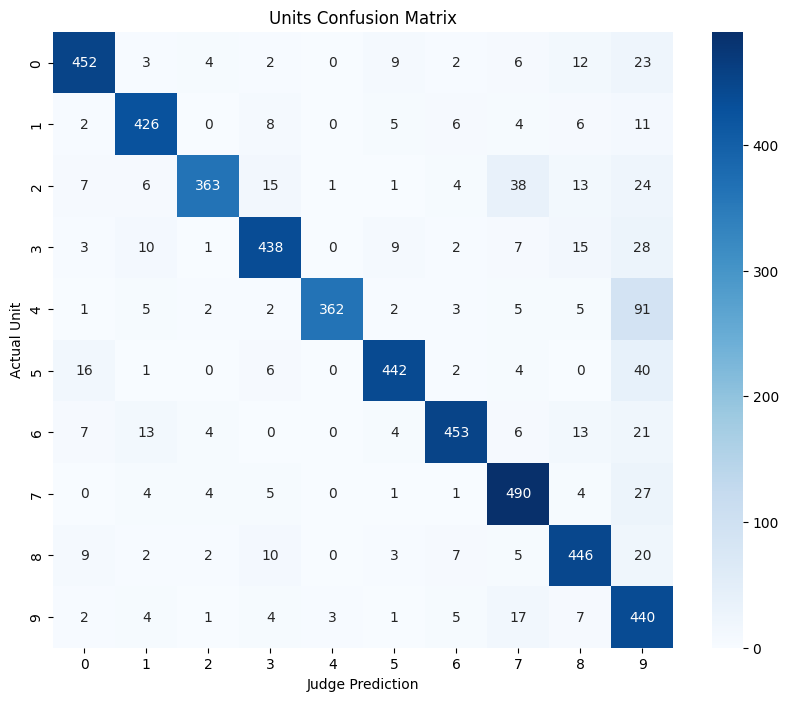

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

latent_dim = 512


def custom_loss(y_true, y_pred):
    mse = tf.keras.losses.MeanSquaredError()(y_true, y_pred)
    ssim = tf.reduce_mean(1 - tf.image.ssim(y_true, y_pred, max_val=1.0))
    l1_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    return mse + ssim + 0.1 * l1_loss

# --- 3. AUTOENCODER (ENCODER & DECODER) ---
# Encoder
enc_in = Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation='relu', padding='same')(enc_in)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
enc_out = layers.Dense(latent_dim, activation='relu')(x)
encoder = models.Model(enc_in, enc_out, name="Encoder")

# Decoder
dec_in = Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(dec_in)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
dec_out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
decoder = models.Model(dec_in, dec_out, name="Decoder")


autoencoder = models.Model(enc_in, decoder(encoder(enc_in)))
autoencoder.compile(optimizer='adam', loss=custom_loss)
print("Training Autoencoder...")
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, verbose=1)

# the cnn claasifier
def build_classifier():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

classifier = build_classifier()
print("Training Judge (Classifier)...")
classifier.fit(x_train, y_train, epochs=5, batch_size=128, verbose=1)

#adder
input_z_a = Input(shape=(latent_dim,))
input_z_b = Input(shape=(latent_dim,))
merged = layers.Concatenate()([input_z_a, input_z_b])
x = layers.Dense(1024, activation='relu')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation='relu')(x)
pred_tens = layers.Dense(latent_dim, name="Tens")(x)
pred_units = layers.Dense(latent_dim, name="Units")(x)
adder_model = models.Model([input_z_a, input_z_b], [pred_tens, pred_units])


real_in_a = Input(shape=(28, 28, 1))
real_in_b = Input(shape=(28, 28, 1))
lat_a, lat_b = encoder(real_in_a), encoder(real_in_b)
tens_lat, units_lat = adder_model([lat_a, lat_b])
full_model = models.Model([real_in_a, real_in_b], [decoder(tens_lat), decoder(units_lat)])


def generate_end_to_end_data(num_samples=50000):
    idx_a = np.random.randint(0, len(x_train), num_samples)
    idx_b = np.random.randint(0, len(x_train), num_samples)
    imgs_a, imgs_b = x_train[idx_a], x_train[idx_b]
    vals_a, vals_b = y_train[idx_a], y_train[idx_b]

    target_tens = np.zeros((num_samples, 28, 28, 1))
    target_units = np.zeros((num_samples, 28, 28, 1))

    for i in range(num_samples):
        total = vals_a[i] + vals_b[i]
        t, u = total // 10, total % 10

        target_units[i] = x_train[y_train == u][np.random.randint(0, 500)]
        if t == 0:
            target_tens[i] = np.zeros((28, 28, 1)) # Blank
        else:
            target_tens[i] = x_train[y_train == t][np.random.randint(0, 500)]

    return [imgs_a, imgs_b], [target_tens, target_units]

X_train_full, Y_train_full = generate_end_to_end_data(50000)

# freezing in order to train the adder
encoder.trainable = False
decoder.trainable = False
full_model.compile(optimizer='adam', loss=custom_loss)

print("Training Full Model (End-to-End Reconstruction)...")
full_model.fit(X_train_full, Y_train_full, epochs=20, batch_size=128, validation_split=0.1)

def evaluate_full_system():
    midpoint = len(x_test) // 2
    samp_a, samp_b = x_test[:midpoint], x_test[midpoint:]
    lbl_a, lbl_b = y_test[:midpoint], y_test[midpoint:]
    true_sums = lbl_a + lbl_b

    # image gen
    pred_imgs_tens, pred_imgs_units = full_model.predict([samp_a, samp_b], batch_size=128)


    pred_labels_units = np.argmax(classifier.predict(pred_imgs_units), axis=1)
    tens_probs = classifier.predict(pred_imgs_tens)

    pred_labels_tens = []
    for i in range(len(samp_a)):
        if np.mean(pred_imgs_tens[i]) < 0.05: # Brightness Check
            pred_labels_tens.append(0)
        else:
            pred_labels_tens.append(np.argmax(tens_probs[i]))

    pred_labels_tens = np.array(pred_labels_tens)
    read_sums = (pred_labels_tens * 10) + pred_labels_units

    # correct predictions
    correct_idx = np.where(read_sums == true_sums)[0]
    wrong_idx = np.where(read_sums != true_sums)[0]

    print(f"\nACCURACY: {np.mean(read_sums == true_sums)*100:.2f}%")
    print("\nCORRECT:")
    for i in range(2):
        idx = correct_idx[i]
        print(f"Sum: {lbl_a[idx]}+{lbl_b[idx]} | Target: {true_sums[idx]} | Prediction: {read_sums[idx]} ")



    # Confusion Matrix
    cm = confusion_matrix(true_sums % 10, pred_labels_units)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Units Confusion Matrix")
    plt.ylabel("Actual Unit")
    plt.xlabel("Judge Prediction")
    plt.show()

evaluate_full_system()

Generating predictions for the test set...
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


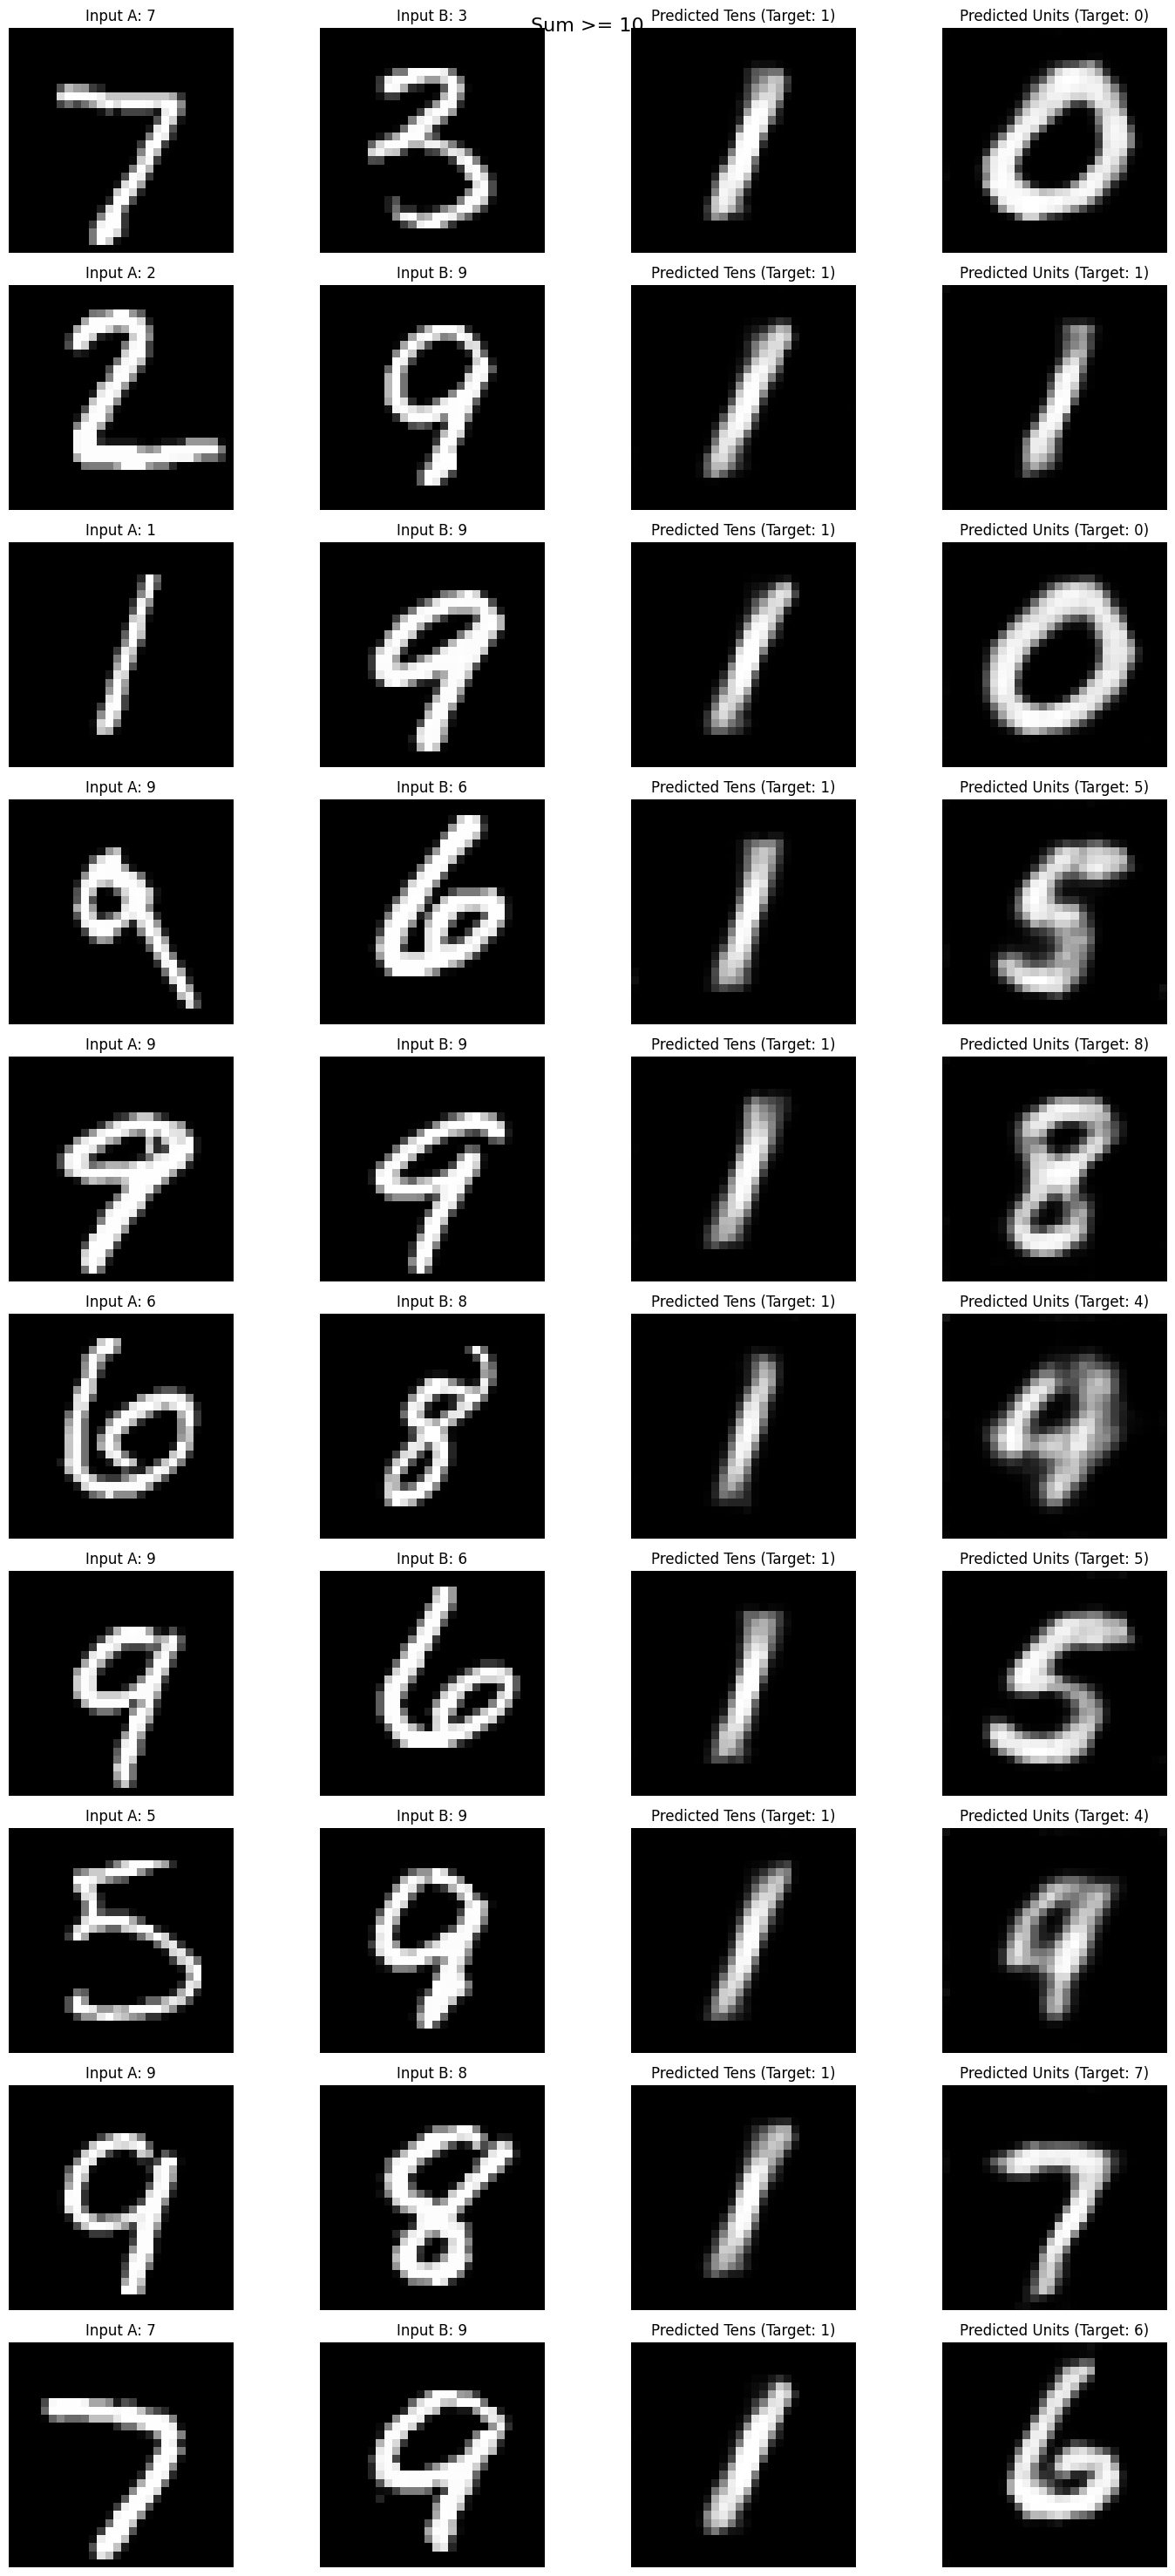

In [3]:
import matplotlib.pyplot as plt
import numpy as np


midpoint = len(x_test) // 2
samp_a, samp_b = x_test[:midpoint], x_test[midpoint:]
lbl_a, lbl_b = y_test[:midpoint], y_test[midpoint:]

print("Generating predictions for the test set...")
pred_imgs_tens, pred_imgs_units = full_model.predict([samp_a, samp_b], batch_size=128)


calculated_sums = lbl_a + lbl_b
idx_ge_10 = np.where(calculated_sums >= 10)[0]
n_show = min(10, len(idx_ge_10))
plt.figure(figsize=(15, n_show * 3))

for i in range(n_show):
    idx = idx_ge_10[i]


    plt.subplot(n_show, 4, i * 4 + 1)
    plt.imshow(samp_a[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Input A: {lbl_a[idx]}")
    plt.axis('off')


    plt.subplot(n_show, 4, i * 4 + 2)
    plt.imshow(samp_b[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Input B: {lbl_b[idx]}")
    plt.axis('off')


    plt.subplot(n_show, 4, i * 4 + 3)
    plt.imshow(pred_imgs_tens[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted Tens (Target: 1)")
    plt.axis('off')

    # prediction
    plt.subplot(n_show, 4, i * 4 + 4)
    plt.imshow(pred_imgs_units[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted Units (Target: {calculated_sums[idx]%10})")
    plt.axis('off')

plt.suptitle("Sum >= 10", fontsize=16)
plt.tight_layout()
plt.show()